# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberto a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b> Resposta </b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-danger">

<b>Comentário geral v1: </b> <a class="tocSkip"></a>

Parabéns pela conclusão do projeto, Lucas! 🎉 Seu projeto já está com uma qualidade muito boa! 
Adicionei uma resposta para sua pergunta sobre a automatização do códigos.


Em caso de dúvidas, não hesite em nos perguntar!

Boa sorte! 🍀 
</div>

# Projeto Sprint 11 - Analise comportamental do usuário

# Introdução

Analise do comportamento do usuário para o aplicativo de uma empresa startup que vende produtos alimentícios.

Aplicação e estudo do funil de vendas. Entendimento de quantos e como os usuários chegam à etapa de compra. Eventos que ocorrem durante todo processo.

Analise dos resultados do teste A/A/B. Os designers gostariam de alterar as fontes de todo o aplicativo. Realização do teste para auxiliar na tomada de decisão com base nos resultados de um teste A/A/B.

## Sumário

1. [Abertura dos dados](#abertura_dados)
    * 1.1 [Verificação de dados duplicados e nulos](#verificacao_dados)
2. [Análise exploratória](#analise_exploratoria)
    * 2.1 [Agrupamentos iniciais](#agrupamentos_iniciais)
    * 2.2 [Gráficos iniciais](#graficos_iniciais)
3. [Hipóteses e Verificações](#verificacoes)
    * 3.1 [Gráficos Rede True and False](#graf_chain)
    * 3.2 [Gráfico Média de Cadeiras](#graf_media)
4. [Análise do negócio por endereço](#df_ruas)
    * 4.1 [Análise dos principais endereços](#df_10)
    * 4.2 [Análise dos principais endereços por Rede True and False](#df_10_TF)
5. [Conclusão](#conclusao)

<a id="abertura_dados"></a>
## 1. Abertura dos dados

In [130]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import math as mth
import seaborn as sns
from plotly import graph_objects as go
import plotly.express as px
import re

In [131]:
# Extraindo o arquivo

df = pd.read_csv('logs_exp_us.csv', sep='\t')
df

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248
...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,1565212345,247
244122,MainScreenAppear,5849806612437486590,1565212439,246
244123,MainScreenAppear,5746969938801999050,1565212483,246
244124,MainScreenAppear,5746969938801999050,1565212498,246


<a id="verificacao_dados"></a>
### 1.1 Preparação dos dados 


In [132]:
# renomeando columnas

df.columns = ['evento','id','data_hora','grupo']
# df

In [133]:
# transformação de data/hora e criação da coluna data

df['data_hora'] = pd.to_datetime(df['data_hora'], unit='s')

df['data'] = df['data_hora'].dt.date

df

,evento,id,data_hora,grupo,data
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25
...,...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,2019-08-07 21:12:25,247,2019-08-07
244122,MainScreenAppear,5849806612437486590,2019-08-07 21:13:59,246,2019-08-07
244123,MainScreenAppear,5746969938801999050,2019-08-07 21:14:43,246,2019-08-07
244124,MainScreenAppear,5746969938801999050,2019-08-07 21:14:58,246,2019-08-07


In [134]:
# exploração inicial

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   evento     244126 non-null  object        
 1   id         244126 non-null  int64         
 2   data_hora  244126 non-null  datetime64[ns]
 3   grupo      244126 non-null  int64         
 4   data       244126 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 9.3+ MB
None


<a id="verificacao_dados"></a>
### 1.2 Verificação de duplicados e nulos 

In [135]:
# nulos e duplicados

print('nulos:\n', df.isna().sum())
print()
print('duplucados: ',df.duplicated().sum())

nulos:
 evento       0
id           0
data_hora    0
grupo        0
data         0
dtype: int64

duplucados:  413


In [136]:
# nulos e duplicados

df_main = df.drop_duplicates()
df_main

,evento,id,data_hora,grupo,data
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25
...,...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,2019-08-07 21:12:25,247,2019-08-07
244122,MainScreenAppear,5849806612437486590,2019-08-07 21:13:59,246,2019-08-07
244123,MainScreenAppear,5746969938801999050,2019-08-07 21:14:43,246,2019-08-07
244124,MainScreenAppear,5746969938801999050,2019-08-07 21:14:58,246,2019-08-07


<a id="analise_exploratoria"></a>
## 2. Análise exploratória

     - Temos 5 tipos de eventos registrados;
     - Usuários estão divididos em 3 grupos de teste, 2 de controle e 1 de teste, e estão em quantidades balanceadas permitindo seguir com as analises;
     - A data a ser condiderada nas analises são a partir do dia 2019-08-01, onde foi vizualizado a contancia de acessos;

In [137]:
# verificação geral de valores unicos

print(df_main['evento'].value_counts())
print()
print(df_main['grupo'].value_counts())
print()
print(df_main['data'].value_counts())

evento
MainScreenAppear           119101
OffersScreenAppear          46808
CartScreenAppear            42668
PaymentScreenSuccessful     34118
Tutorial                     1018
Name: count, dtype: int64

grupo
248    85582
246    80181
247    77950
Name: count, dtype: int64

data
2019-08-01    36141
2019-08-05    36058
2019-08-06    35788
2019-08-02    35554
2019-08-03    33282
2019-08-04    32968
2019-08-07    31096
2019-07-31     2030
2019-07-30      412
2019-07-29      184
2019-07-28      105
2019-07-27       55
2019-07-26       31
2019-07-25        9
Name: count, dtype: int64


Quantos eventos ficam nos registros?
Quantos usuários ficam nos registros?
Qual é o número médio de eventos por usuário?
Qual é o período de tempo que os dados cobrem? Encontre as datas máxima e mínima. Desenhe um histograma por data e hora. Você pode ter certeza de que possui os dados igualmente completos para todo o período? Os eventos mais antigos podem acabar aparecendo nos diários de alguns usuários por motivos técnicos, e isso pode distorcer o quadro geral. Encontre o momento em que os dados começam a ser completos e ignore a seção anterior. Qual período os dados realmente representam?
Você perdeu muitos eventos e usuários ao excluir os dados mais antigos?
Certifique-se de ter usuários de todos os três grupos experimentais.

In [138]:
qtd_evento = df_main['evento'].nunique()
print('eventos registrados: ',qtd_evento)

eventos registrados:  5


In [139]:
qtd_id = df_main['id'].nunique()
print('usuarios registrados: ',qtd_id)

usuarios registrados:  7551


In [140]:
group_id_eve = df_main.groupby('grupo').agg({'id':'nunique'})
print('usuarios registrados por grupo de teste: ',group_id_eve)

usuarios registrados por grupo de teste:           id
grupo      
246    2489
247    2520
248    2542


In [141]:
qtd_id_evento = df_main.groupby('id').agg({'evento':'count'}).reset_index()

qtd_id_evento['media'] = qtd_id_evento['evento'] / (df_main['evento'].nunique())
print(qtd_id_evento)

print()
print('Número médio de eventos por usuário: ', qtd_id_evento['media'].mean())


                       id  evento  media
0        6888746892508752       1    0.2
1        6909561520679493       5    1.0
2        6922444491712477      47    9.4
3        7435777799948366       6    1.2
4        7702139951469979     137   27.4
...                   ...     ...    ...
7546  9217594193087726423       9    1.8
7547  9219463515465815368      17    3.4
7548  9220879493065341500       7    1.4
7549  9221926045299980007       7    1.4
7550  9222603179720523844      59   11.8

[7551 rows x 3 columns]

Número médio de eventos por usuário:  6.455118527347371


<div class="alert alert-block alert-success">
<b> Comentário: </b> <a class="tocSkip"></a>
  
As estatísticas dos usuários foram analisadas
</div>

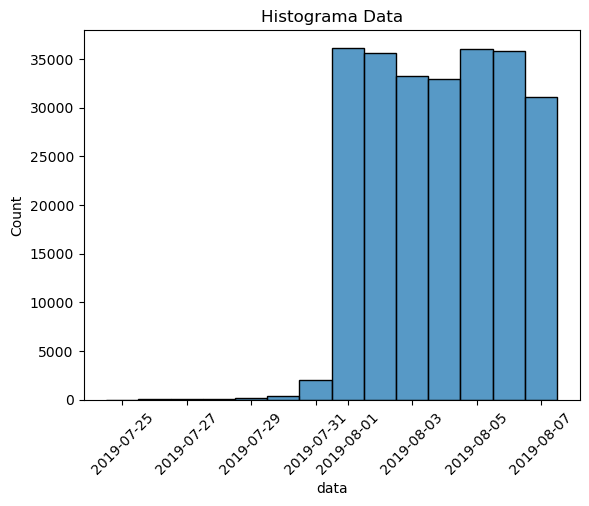

In [142]:
# Histograma para verificação do inicio acertivo do teste

sns.histplot(df_main['data'],)
plt.xticks(rotation=45)
plt.title('Histograma Data')
plt.show()

In [143]:
# defenindo o dataframe de teste com a data a partir do dia 2019-08-01

inicio = pd.to_datetime('2019-07-31').date()

df_teste = df_main[df_main['data'] > inicio]
print(df_teste['data'].value_counts())

data
2019-08-01    36141
2019-08-05    36058
2019-08-06    35788
2019-08-02    35554
2019-08-03    33282
2019-08-04    32968
2019-08-07    31096
Name: count, dtype: int64


<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip">
    
- A análise temporal foi realizada corretamente 
- Gráficos muito bons! Parabéns!

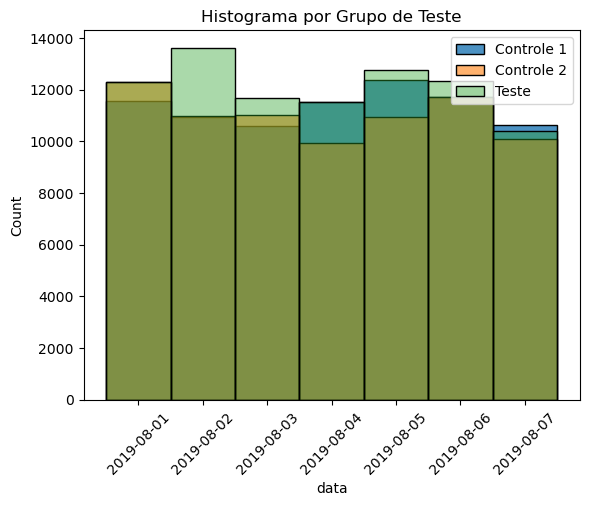

In [144]:
# separacao entre os grupos de teste para verificar as frequencias

gc1 = df_teste[df_teste['grupo'] == 246]
gc2 = df_teste[df_teste['grupo'] == 247]
gt = df_teste[df_teste['grupo'] == 248]


sns.histplot(
    gc1['data'],
    # x='data',
    alpha=0.8)
sns.histplot(
    gc2['data'],
    # x='data',
    alpha=0.6)
sns.histplot(
    gt['data'],
    # x='data',
    alpha=0.4)

plt.legend(['Controle 1','Controle 2','Teste'])
plt.title('Histograma por Grupo de Teste')
plt.xticks(rotation=45)
plt.show()

<a id="analise_exploratoria"></a>
## 3. Funil de eventos


Veja quais eventos estão nos diários e sua frequência de ocorrência. Classifique-os por frequência.

Encontre o número de usuários que executaram cada uma dessas ações. Ordene os eventos pelo número de usuários. Calcule a proporção de usuários que executaram a ação pelo menos uma vez.

Em que ordem você acha que as ações ocorreram? Todos elas fazem parte de uma única sequência? Você não precisa levá-las em consideração ao calcular o funil.

Use o funil de eventos para encontrar a parcela de usuários que passam de uma etapa para a próxima (por exemplo, para a sequência de eventos A → B → C, calcule a proporção de usuários na etapa B para o número de usuários na etapa A e a proporção de usuários na etapa C para o número na etapa B).

Em qual fase você perde mais usuários?

Qual é a parcela de usuários que faz o caminho inteiro, desde o primeiro evento até o pagamento?

<a id="analise_exploratoria"></a>
### 3.1 Frequências de eventos

In [145]:
# frequencia absoluta e relativa dos eventos

freq_event = df_teste['evento'].value_counts().reset_index()
freq_event['relativa'] = freq_event['count'] / (freq_event['count'].sum())
freq_event.columns = ['evento','absoluta','relativa']
freq_event 

,evento,absoluta,relativa
0,MainScreenAppear,117328,0.487067
1,OffersScreenAppear,46333,0.192343
2,CartScreenAppear,42303,0.175613
3,PaymentScreenSuccessful,33918,0.140805
4,Tutorial,1005,0.004172


In [146]:
# frequencia absoluta e relativa dos eventos

pivot_table = df_teste.pivot_table(index='data',
                                columns='evento',
                                values='id',
                                aggfunc='nunique',
                                margins=True).reset_index()
pivot_table

evento,data,CartScreenAppear,MainScreenAppear,OffersScreenAppear,PaymentScreenSuccessful,Tutorial,All
0,2019-08-01,1510,3545,2050,1372,155,3703
1,2019-08-02,1525,3485,2070,1394,145,3647
2,2019-08-03,1505,3301,2072,1413,143,3482
3,2019-08-04,1517,3354,2085,1424,130,3527
4,2019-08-05,1547,3608,2151,1447,99,3802
5,2019-08-06,1528,3766,2167,1454,118,3922
6,2019-08-07,1434,3482,2062,1361,69,3651
7,All,3734,7419,4593,3539,840,7534


<a id="analise_exploratoria"></a>
### 3.2 Fluxo do Processo compra

Analise pela quantidade de acessos:
    Fluxo do processo:
     - Evento A: Tutorial
     - Evento B: MainScreenAppear
     - Evento C: OffersScreenAppear
     - Evento D: CartScreenAppear
     - Evento E: PaymentScreenSuccessful

Analise pela horário dos acessos:
    Fluxo do processo:
     - Evento A: Tutorial
     - Evento B: MainScreenAppear
     - Evento C: CartScreenAppear
     - Evento D: PaymentScreenSuccessful
     - Evento E: OffersScreenAppear

Analise pelo processo de compra:
    Fluxo do processo:
     - Evento A: MainScreenAppear
     - Evento B: CartScreenAppear
     - Evento C: PaymentScreenSuccessful

OBS: poucos usuários realisaram a fase do Evento Tutorial
Processos não obrigatórios: Evento Tutorial e Evento OffersScreenAppear

     - Como saber se um usuário realizou mais de uma compra? 
     - Pelo ID do User ficamos restrito a somente uma compra, deveria ter um ID de compra para poder separar casos com mais de uma compra

In [147]:
# Tabela dinamica com data/hora de cada evento - verificação de eventos sequenciais

df_data_hora = df_teste.pivot_table(index='id',
                                    columns='evento',
                                    values='data_hora',
                                    aggfunc='min')
# df_data_hora
print(df_data_hora[~df_data_hora['PaymentScreenSuccessful'].isna()])

evento                 CartScreenAppear    MainScreenAppear  \
id                                                            
6909561520679493    2019-08-06 18:52:58 2019-08-06 18:52:54   
6922444491712477    2019-08-04 14:19:40 2019-08-04 14:19:33   
7702139951469979    2019-08-02 14:28:45 2019-08-01 04:29:54   
9841258664663090    2019-08-03 10:52:15 2019-08-03 10:47:59   
15708180189885246   2019-08-01 11:06:19 2019-08-01 16:08:23   
...                                 ...                 ...   
9212961170535635779 2019-08-05 15:16:36 2019-08-01 04:30:59   
9214668690707156694 2019-08-03 10:58:25 2019-08-01 10:18:23   
9216369613838971606 2019-08-02 12:05:54 2019-08-02 12:05:48   
9217594193087726423 2019-08-02 09:00:58                 NaT   
9219463515465815368 2019-08-06 16:49:40 2019-08-05 05:26:26   

evento               OffersScreenAppear PaymentScreenSuccessful  \
id                                                                
6909561520679493    2019-08-06 18:53:04     20

<a id="analise_exploratoria"></a>
### 3. Funis de Produtos com Sequência de Eventos

In [148]:
# Parcela de users por evento e funil

# filtro condicional de que cada etapa foi realizada - sem nulo na etapa anterior
check_AB = ~df_data_hora['MainScreenAppear'].isna()
check_BC = check_AB & (df_data_hora['CartScreenAppear'] >= df_data_hora['MainScreenAppear'])
check_CD = check_BC & (df_data_hora['PaymentScreenSuccessful'] >= df_data_hora['CartScreenAppear'])

# lista > formato > número
n_main = df_data_hora[check_AB].shape[0]
n_cart = df_data_hora[check_BC].shape[0]
n_payment = df_data_hora[check_CD].shape[0]

print('Quantidade de usuários na etapa/tela A - Main: ', n_main)
print()
print('Quantidade de usuários na etapa/tela B - Cart: ', n_cart)
print()
print('Quantidade de usuários na etapa/tela C - Payment: ', n_payment)

# Cálculo do Funil
funil_AB = n_cart / n_main
funil_BC = n_payment / n_cart 

print()
print('Funil A B - Main Cart: ', funil_AB)
print()
print('Funil B C - Cart Pay: ', funil_BC)

Quantidade de usuários na etapa/tela A - Main:  7419

Quantidade de usuários na etapa/tela B - Cart:  3432

Quantidade de usuários na etapa/tela C - Payment:  2570

Funil A B - Main Cart:  0.4625960372017792

Funil B C - Cart Pay:  0.7488344988344988


In [149]:
# Pacela de users que finalizaram o ciclo de compra

funil_AC = n_payment / n_main

print('Funil A C - Main Pay: ', funil_AC)

Funil A C - Main Pay:  0.3464078716808195


In [150]:
# # funil_event = df_teste['evento'].value_counts().reset_index()
# df_teste1 = df_teste.copy()
# df_teste1['conversion_rate'] = df_teste1['id'] / df_teste1['id'].shift(1)

# fig_funil = go.Figure(go.Funnel(y= df_teste1['evento'], x= df_teste1['id']))

# fig_funil = px.funnel(y= df_teste1['evento'], x= df_teste1['id'])
# fig_funil.show()

<div class="alert alert-info">
<strong>Comentário do estudante v1</strong>

    Gráfico de Funil esta crashando tanto do o 'go' quanto com o 'px'
</div>

<div class="alert alert-block alert-warning">
<b> Comentário: </b> <a class="tocSkip"></a>
    

Sugestão:    
Caso você queira criar um funil de eventos para visualização:
    
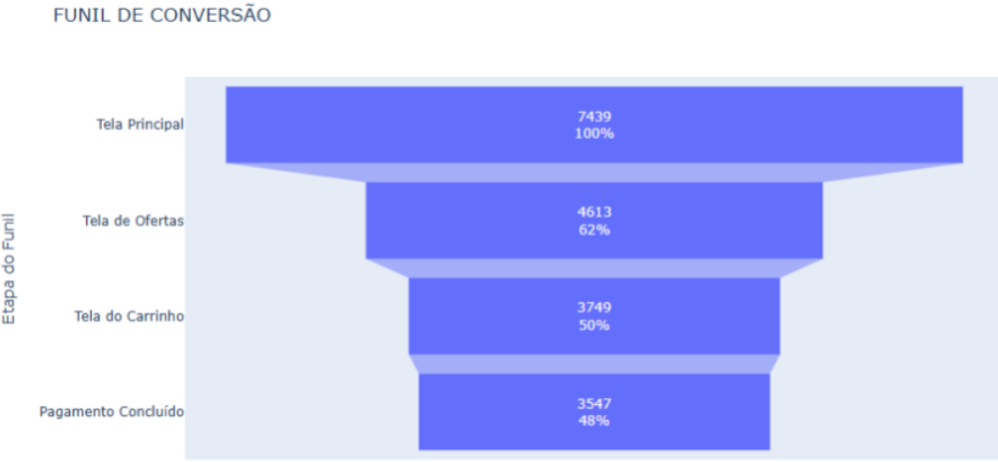
    
```python
import matplotlib.pyplot as plt
from plotly import graph_objects as go
    
# Calcula a taxa de conversão dividindo o número de usuários atual pelo número de usuários da iteração anterior
user_event['conversion_rate'] = user_event['id_user'] / user_event['id_user'].shift(1)

# Cria um gráfico de funil usando a biblioteca plotly.graph_objects (go)
# 'y' define os eventos do funil e 'x' define o número de usuários em cada etapa
fig = go.Figure(go.Funnel(y = user_event['name_event'], x = user_event['id_user']))

# Exibe o gráfico
fig.show()
```

<a id="teste_proporcao"></a>
## 4. Teste Hipótese de que as Proporções de Eventos são Iguais

<a id="teste_proporcao_a1a2"></a>
### 4.1 Teste Proporções A1 A2 | grupos 246 - 247

In [151]:
# verificação de valores individuais e progrecao do raciocinio

grupo1 = 246
grupo2 = 247
total_users = df_teste[df_teste['grupo'].isin([grupo1,grupo2])].groupby('grupo')['id'].nunique()
print('total_users',total_users)

evento_users = df[(df['grupo'].isin([grupo1,grupo2])) &
                  (df['evento'] == 'MainScreenAppear')].groupby('grupo')['id'].nunique()
print('evento_users',evento_users)
                
# numero de sucessos de evento por cada grupo
sucessos1 = evento_users.loc[[grupo1,grupo2]].values
print('sucessos1',sucessos1)

# numero de tentativas de acesso de users em cada grupo
tentativa1 = total_users.loc[[grupo1,grupo2]].values
print('tentativa1',tentativa1)

# calculo das proporcoes de sucesso por cada grupo
p1 = sucessos1[0] / tentativa1[0]
p2 = sucessos1[1] / tentativa1[1]
print('p1 = sucessos1[0] / tentativa1[0]',p1)
print('p2 = sucessos1[1] / tentativa1[1]',p2)

# proporcao combinada entre od dois grupos
p_comb1 = (sucessos1[0] + sucessos1[1]) / (tentativa1[0] + tentativa1[1])
print('p_comb1 = (sucessos1[0] + sucessos1[1]) / (tentativa1[0] + tentativa1[1])',p_comb1)

# diferenca entre as proporcoes dos grupos
diferenca = p1 - p2
print('diferenca = p1 - p2',diferenca)

# calculo do valor z - estatistica do teste z para proporcoes
z_value = diferenca / mth.sqrt(p_comb1 * (1 - p_comb1) * (1/tentativa1[0] + 1/tentativa1[1]))
print('z_value = diferenca / mth.sqrt(p_comb1 * (1 - p_comb1) * (1/tentativa1[0] + 1/tentativa1[1]))',z_value)

# definicao da distribuicao normal padrao
distrib = st.norm(0,1)
        
# calculo do p-value
p_value = (1 - distrib.cdf(abs(z_value))) * 2
print('p_value = (1 - distrib.cdf(abs(z_value))) * 2',p_value)

# visualizacao dos resultados
# print(f"Evento: {evento} | p-value: {p_value}")
# print()

# # verificacao do p-value em relacao ao nivel de significancia alpha adotado
# if p_value < alpha:
#     print('Diferença significativa entre os grupos')
# else:
#     print('Grupos semelhantes nesse evento')

# # execução da função
# for event in df['evento'].nunique():
#     teste_AA_main1(event, 246, 247, df_teste)
#     print()

total_users grupo
246    2484
247    2513
Name: id, dtype: int64
evento_users grupo
246    2456
247    2482
Name: id, dtype: int64
sucessos1 [2456 2482]
tentativa1 [2484 2513]
p1 = sucessos1[0] / tentativa1[0] 0.9887278582930756
p2 = sucessos1[1] / tentativa1[1] 0.9876641464385197
p_comb1 = (sucessos1[0] + sucessos1[1]) / (tentativa1[0] + tentativa1[1]) 0.9881929157494497
diferenca = p1 - p2 0.0010637118545558932
z_value = diferenca / mth.sqrt(p_comb1 * (1 - p_comb1) * (1/tentativa1[0] + 1/tentativa1[1])) 0.34805603256140066
p_value = (1 - distrib.cdf(abs(z_value))) * 2 0.7277981031869922


In [152]:
# função otimizada para os testes de proporcao

def teste_A1A2(evento, grupo1, grupo2, df, alpha=0.05):
    
    # Total de users por grupo
    total_users = df[df['grupo'].isin([grupo1,grupo2])].groupby('grupo')['id'].nunique()

    # Numero de usuarios por evento e grupo
    evento_users = df[(df['grupo'].isin([grupo1,grupo2])) &
                      (df['evento'] == evento)].groupby('grupo')['id'].nunique()
    
    # numero de sucessos de evento por cada grupo
    sucessos1 = evento_users.loc[[grupo1,grupo2]].values

    # numero de tentativas de acesso de users em cada grupo
    tentativa1 = total_users.loc[[grupo1,grupo2]].values

    # calculo das proporcoes de sucesso por cada grupo
    p1 = sucessos1[0] / tentativa1[0]
    p2 = sucessos1[1] / tentativa1[1]

    # proporcao combinada entre od dois grupos
    p_comb1 = (sucessos1[0] + sucessos1[1]) / (tentativa1[0] + tentativa1[1])

    # diferenca entre as proporcoes dos grupos
    diferenca = p1 - p2

    # calculo do valor z - estatistica do teste z para proporcoes
    z_value = diferenca / mth.sqrt(p_comb1 * (1 - p_comb1) * (1/tentativa1[0] + 1/tentativa1[1]))

    # definicao da distribuicao normal padrao
    distrib = st.norm(0,1)
    
    # calculo do p-value
    p_value = (1 - distrib.cdf(abs(z_value))) * 2

    # visualizacao dos resultados
    print(f"Evento: {evento} | p-value: {p_value}")
    print()

    # verificacao do p-value em relacao ao nivel de significancia alpha adotado
    if p_value < alpha:
        print('Diferença significativa entre os grupos')
        print()
    else:
        print('Grupos semelhantes nesse evento')
        print()

# execução da função
for event in df_teste['evento'].unique():
    teste_A1A2(event, 246, 247, df_teste)
    print(teste_A1A2)
    print()


Evento: Tutorial | p-value: 0.9376996189257114

Grupos semelhantes nesse evento

<function teste_A1A2 at 0x00000204B4A82980>

Evento: MainScreenAppear | p-value: 0.7570597232046099

Grupos semelhantes nesse evento

<function teste_A1A2 at 0x00000204B4A82980>

Evento: OffersScreenAppear | p-value: 0.2480954578522181

Grupos semelhantes nesse evento

<function teste_A1A2 at 0x00000204B4A82980>

Evento: CartScreenAppear | p-value: 0.22883372237997213

Grupos semelhantes nesse evento

<function teste_A1A2 at 0x00000204B4A82980>

Evento: PaymentScreenSuccessful | p-value: 0.11456679313141849

Grupos semelhantes nesse evento

<function teste_A1A2 at 0x00000204B4A82980>



<a id="teste_proporcao_a1b"></a>
### 4.2 Teste Proporções A1 B | grupos 246 - 248

In [153]:
# função otimizada para os testes de proporcao

def teste_A1B(evento, grupo1, grupo2, df, alpha=0.05):
    
    # Total de users por grupo
    total_users = df[df['grupo'].isin([grupo1,grupo2])].groupby('grupo')['id'].nunique()

    # Numero de usuarios por evento e grupo
    evento_users = df[(df['grupo'].isin([grupo1,grupo2])) &
                      (df['evento'] == evento)].groupby('grupo')['id'].nunique()
    
    # numero de sucessos de evento por cada grupo
    sucessos1 = evento_users.loc[[grupo1,grupo2]].values

    # numero de tentativas de acesso de users em cada grupo
    tentativa1 = total_users.loc[[grupo1,grupo2]].values

    # calculo das proporcoes de sucesso por cada grupo
    p1 = sucessos1[0] / tentativa1[0]
    p2 = sucessos1[1] / tentativa1[1]

    # proporcao combinada entre od dois grupos
    p_comb1 = (sucessos1[0] + sucessos1[1]) / (tentativa1[0] + tentativa1[1])

    # diferenca entre as proporcoes dos grupos
    diferenca = p1 - p2

    # calculo do valor z - estatistica do teste z para proporcoes
    z_value = diferenca / mth.sqrt(p_comb1 * (1 - p_comb1) * (1/tentativa1[0] + 1/tentativa1[1]))

    # definicao da distribuicao normal padrao
    distrib = st.norm(0,1)
    
    # calculo do p-value
    p_value = (1 - distrib.cdf(abs(z_value))) * 2

    # visualizacao dos resultados
    print(f"Evento: {evento} | p-value: {p_value}")
    print()

    # verificacao do p-value em relacao ao nivel de significancia alpha adotado
    if p_value < alpha:
        print('Diferença significativa entre os grupos')
        print()
    else:
        print('Grupos semelhantes nesse evento')
        print()

# execução da função
for event in df_teste['evento'].unique():
    teste_A1B(event, 246, 248, df_teste)
    print(teste_A1B)
    print()


Evento: Tutorial | p-value: 0.8264294010087645

Grupos semelhantes nesse evento

<function teste_A1B at 0x00000204B4B49A80>

Evento: MainScreenAppear | p-value: 0.2949721933554552

Grupos semelhantes nesse evento

<function teste_A1B at 0x00000204B4B49A80>

Evento: OffersScreenAppear | p-value: 0.20836205402738917

Grupos semelhantes nesse evento

<function teste_A1B at 0x00000204B4B49A80>

Evento: CartScreenAppear | p-value: 0.07842923237520116

Grupos semelhantes nesse evento

<function teste_A1B at 0x00000204B4B49A80>

Evento: PaymentScreenSuccessful | p-value: 0.2122553275697796

Grupos semelhantes nesse evento

<function teste_A1B at 0x00000204B4B49A80>



<a id="teste_proporcao_a2b"></a>
### 4.2 Teste Proporções A2 B | grupos 247 - 248

In [154]:
# função otimizada para os testes de proporcao

def teste_A2B(evento, grupo1, grupo2, df, alpha=0.05):
    
    # Total de users por grupo
    total_users = df[df['grupo'].isin([grupo1,grupo2])].groupby('grupo')['id'].nunique()

    # Numero de usuarios por evento e grupo
    evento_users = df[(df['grupo'].isin([grupo1,grupo2])) &
                      (df['evento'] == evento)].groupby('grupo')['id'].nunique()
    
    # numero de sucessos de evento por cada grupo
    sucessos1 = evento_users.loc[[grupo1,grupo2]].values

    # numero de tentativas de acesso de users em cada grupo
    tentativa1 = total_users.loc[[grupo1,grupo2]].values

    # calculo das proporcoes de sucesso por cada grupo
    p1 = sucessos1[0] / tentativa1[0]
    p2 = sucessos1[1] / tentativa1[1]

    # proporcao combinada entre od dois grupos
    p_comb1 = (sucessos1[0] + sucessos1[1]) / (tentativa1[0] + tentativa1[1])

    # diferenca entre as proporcoes dos grupos
    diferenca = p1 - p2

    # calculo do valor z - estatistica do teste z para proporcoes
    z_value = diferenca / mth.sqrt(p_comb1 * (1 - p_comb1) * (1/tentativa1[0] + 1/tentativa1[1]))

    # definicao da distribuicao normal padrao
    distrib = st.norm(0,1)
    
    # calculo do p-value
    p_value = (1 - distrib.cdf(abs(z_value))) * 2

    # visualizacao dos resultados
    print(f"Evento: {evento} | p-value: {p_value}")
    print()

    # verificacao do p-value em relacao ao nivel de significancia alpha adotado
    if p_value < alpha:
        print('Diferença significativa entre os grupos')
        print()
    else:
        print('Grupos semelhantes nesse evento')
        print()

# execução da função
for event in df_teste['evento'].unique():
    teste_A2B(event, 247, 248, df_teste)
    print(teste_A2B)
    print()


Evento: Tutorial | p-value: 0.765323922474501

Grupos semelhantes nesse evento

<function teste_A2B at 0x00000204B1625120>

Evento: MainScreenAppear | p-value: 0.4587053616621515

Grupos semelhantes nesse evento

<function teste_A2B at 0x00000204B1625120>

Evento: OffersScreenAppear | p-value: 0.9197817830592261

Grupos semelhantes nesse evento

<function teste_A2B at 0x00000204B1625120>

Evento: CartScreenAppear | p-value: 0.5786197879539783

Grupos semelhantes nesse evento

<function teste_A2B at 0x00000204B1625120>

Evento: PaymentScreenSuccessful | p-value: 0.7373415053803964

Grupos semelhantes nesse evento

<function teste_A2B at 0x00000204B1625120>



<div class="alert alert-info">
<strong>Comentário do estudante v0</strong>

    Não consegui pensar em uma maneira inteligente de realizar os testes com um unico codigo, acabei realizando uma prévia para saber se estou no caminho certo e saber se há algum direcionamento para auxiliar nos testes e interpretações.
</div>

<div class="alert alert-block alert-info">
<b>Resposta: </b> <a class="tocSkip"></a>
    
Oi, Carlos! Ótima pergunta!
É sempre bom buscar formas de automatizar e otimizar o código. Abaixo, segue um passo a passo de como você pode tornar o teste mais eficiente:
 
```python 

'''Teste estatístico para cada evento nos grupos de controle'''

# Importações necessárias (garanta que math e scipy.stats estejam importados como mth e st)
import math as mth
import scipy.stats as st

# Função para fazer o teste de diferença estatística entre proporções de dois grupos
def test_proportions(event, group1, group2, df, alpha=0.05):
    # Total de usuários únicos em cada grupo
    total_users = df[df['group'].isin([group1, group2])].groupby('group')['user_id'].nunique()

    # Número de usuários que realizaram o evento em cada grupo
    event_users = df[(df['group'].isin([group1, group2])) &
                     (df['event_name'] == event)].groupby('group')['user_id'].nunique()

    # Número de sucessos (usuários que realizaram o evento) para cada grupo
    successes = event_users.loc[[group1, group2]].values

    # Número total de usuários (tentativas) em cada grupo
    trials = total_users.loc[[group1, group2]].values

    # Cálculo das proporções de sucesso para cada grupo
    p1 = successes[0] / trials[0]
    p2 = successes[1] / trials[1]

    # Proporção combinada entre os dois grupos
    p_combined = (successes[0] + successes[1]) / (trials[0] + trials[1])

    # Diferença entre as proporções dos dois grupos
    difference = p1 - p2

    # Cálculo do valor z (estatística do teste z para proporções)
    z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1]))

    # Definição da distribuição normal padrão
    distr = st.norm(0, 1)

    # Cálculo do p-valor (teste bicaudal)
    p_value = (1 - distr.cdf(abs(z_value))) * 2

    # Impressão dos resultados
    print(f"Evento: {event}")
    print(f"p-value: {p_value:.5f}")

    # Verificação se o p-valor é menor que o nível de significância (alpha)
    if p_value < alpha:
        print("Diferença significativa entre os grupos!")
    else:
        print("Grupos semelhantes nesse evento.")

# Executa o teste de proporções para cada evento entre os grupos de controle A/A (ex: 246 e 247)
for event in df_['event_name'].unique():
    test_proportions(event, 246, 247, df_)
    print()


```

Por favor tente adaptar o código para seu projeto.

<a id="teste_AAB"></a>
## 5. Teste A A B

    Verificação das médias e variâncias dos grupos;
    
    Teste de Hipóteses de que as médias dos grups comparados são estatisticamente iguais;
    
    Nível de significância: 5% - 0.05
    Valor padrão de 5% pois não é considerada uma operação crítica

    Teste A/B - hipótese de que a as médias do teste são iguais e não houve alteração/ganhos

    Diferença relativa entre os grupos - ganho ou perda de clientes

    Gráfico cumulativo - verificação da estabilização

In [155]:
# separacao entre os grupos de teste para verificar as frequencias

gc1 = df_teste[df_teste['grupo'] == 246]
gc2 = df_teste[df_teste['grupo'] == 247]
gt = df_teste[df_teste['grupo'] == 248]

lista_grupo = df_teste['grupo'].value_counts().reset_index()
lista_evento = df_teste['evento'].value_counts().reset_index()


print(lista_grupo) # quantidade de users por grupo
print()
print(lista_evento) # quantidade de users por evento
print()
pivot_table = df_teste.pivot_table(index='data',
                                columns='evento',
                                values='id',
                                aggfunc='nunique',
                                margins=True).reset_index()
print(pivot_table) # quantidade de users por data / evento - alterando o df é possivel verificar tambem por grupo


   grupo  count
0    248  84563
1    246  79302
2    247  77022

                    evento   count
0         MainScreenAppear  117328
1       OffersScreenAppear   46333
2         CartScreenAppear   42303
3  PaymentScreenSuccessful   33918
4                 Tutorial    1005

evento        data  CartScreenAppear  MainScreenAppear  OffersScreenAppear  \
0       2019-08-01              1510              3545                2050   
1       2019-08-02              1525              3485                2070   
2       2019-08-03              1505              3301                2072   
3       2019-08-04              1517              3354                2085   
4       2019-08-05              1547              3608                2151   
5       2019-08-06              1528              3766                2167   
6       2019-08-07              1434              3482                2062   
7              All              3734              7419                4593   

evento  PaymentScreen

<a id="teste_A1A2"></a>
### 4. Teste A1 A2 - grupos 246 247 - evento Main

In [156]:
# Definição de dataframes separados para cada grupo e cada evento
# grupos 246 247 248 - evento Main

main246_e = df_teste[df_teste['evento'] == 'MainScreenAppear']
main246_g = main246_e[main246_e['grupo'] == 246]

gc_main246 = main246_g.groupby('id').agg({'evento':'count'})



main247_e = df_teste[df_teste['evento'] == 'MainScreenAppear']
main247_g = main247_e[main247_e['grupo'] == 247]

gc_main247 = main247_g.groupby('id').agg({'evento':'count'})



main248_e = df_teste[df_teste['evento'] == 'MainScreenAppear']
main248_g = main248_e[main248_e['grupo'] == 248]

gc_main248 = main248_g.groupby('id').agg({'evento':'count'})

alpha = 0.05
ttest_246_247 = st.ttest_ind(gc_main246, gc_main247, equal_var=True)


     - Teste hipóteses médias iguais: não podemos descartar a hipótese nula de médias iguais
     - Teste A1 A2:  Grupos semelhantes, ambos testes possuem relevância para o teste A / B
     Ganho relativo de 2.6%

In [157]:
print('média 246: ', gc_main246.mean())
print('média 247: ', gc_main247.mean())
print()

print('variância 246: ', np.var(gc_main246, axis=0))
print('variância 247: ', np.var(gc_main247, axis=0))
print()

print('T test - p-valor: ', ttest_246_247.pvalue)
    # Verificação se o p-valor é menor que o nível de significância (alpha)
if (ttest_246_247.pvalue) < alpha:
    print("Hipótese Nula: As médias do grupos são semelhantes/iguais")
else:
    print("Hipótese Alternativa: As médias do grupos são diferentes")
print()

print('Teste A1/A2 - p-valor: ',st.mannwhitneyu(gc_main246,gc_main247)[1])
if (st.mannwhitneyu(gc_main246,gc_main247)[1]) < alpha:
    print("Diferença significativa entre os grupos!")
else:
    print("Grupos semelhantes nesse evento.")
print()

print('Diferença relativa estre os testes: ', gc_main247.mean() / gc_main246.mean()-1)

média 246:  evento    15.377959
dtype: float64
média 247:  evento    15.787561
dtype: float64

variância 246:  evento    236.315106
dtype: float64
variância 247:  evento    274.467794
dtype: float64

T test - p-valor:  [0.36865699]
Hipótese Alternativa: As médias do grupos são diferentes

Teste A1/A2 - p-valor:  [0.66158766]
Grupos semelhantes nesse evento.

Diferença relativa estre os testes:  evento    0.026636
dtype: float64


<a id="teste_A1B"></a>
### 4. Teste A1 B - grupos 246 248 - evento Main

In [158]:
# Definição de dataframes separados para cada grupo e cada evento
# grupos 246 247 248 - evento Main

main246_e = df_teste[df_teste['evento'] == 'MainScreenAppear']
main246_g = main246_e[main246_e['grupo'] == 246]

gc_main246 = main246_g.groupby('id').agg({'evento':'count'})



main247_e = df_teste[df_teste['evento'] == 'MainScreenAppear']
main247_g = main247_e[main247_e['grupo'] == 247]

gc_main247 = main247_g.groupby('id').agg({'evento':'count'})



main248_e = df_teste[df_teste['evento'] == 'MainScreenAppear']
main248_g = main248_e[main248_e['grupo'] == 248]

gc_main248 = main248_g.groupby('id').agg({'evento':'count'})

alpha = 0.05
ttest_246_248 = st.ttest_ind(gc_main246, gc_main248, equal_var=True)

     - Teste hipóteses médias iguais: Hipótese Nula: As médias do grupos são semelhantes/iguais
     - Teste A1 B: Grupos semelhantes nesse teste A1 / B
     Ganho relativo para o teste A1 / B de 5,8%

In [159]:
print('média 246: ', gc_main246.mean())
print('média 248: ', gc_main248.mean())
print()

print('variância 246: ', np.var(gc_main246, axis=0))
print('variância 248: ', np.var(gc_main248, axis=0))
print()

print('T test - p-valor: ', ttest_246_248.pvalue)
if (ttest_246_248.pvalue) < alpha:
    print("Hipótese Nula: As médias do grupos são semelhantes/iguais")
else:
    print("Hipótese Alternativa: As médias do grupos são diferentes")
print()

print('Teste A1/B - p-valor: ',st.mannwhitneyu(gc_main246,gc_main248)[1])
if (st.mannwhitneyu(gc_main246,gc_main248)[1]) < alpha:
    print("Diferença significativa entre os grupos!")
else:
    print("Grupos semelhantes nesse evento.")
print()

print('Diferença relativa estre os testes: ', gc_main248.mean() / gc_main246.mean()-1)

média 246:  evento    15.377959
dtype: float64
média 248:  evento    16.270357
dtype: float64

variância 246:  evento    236.315106
dtype: float64
variância 248:  evento    261.834649
dtype: float64

T test - p-valor:  [0.04699786]
Hipótese Nula: As médias do grupos são semelhantes/iguais

Teste A1/B - p-valor:  [0.0954555]
Grupos semelhantes nesse evento.

Diferença relativa estre os testes:  evento    0.058031
dtype: float64


<a id="teste_A2B"></a>
### 4. Teste A2 B - grupos 247 248 - evento Main

In [160]:
# Definição de dataframes separados para cada grupo e cada evento
# grupos 246 247 248 - evento Main

main246_e = df_teste[df_teste['evento'] == 'MainScreenAppear']
main246_g = main246_e[main246_e['grupo'] == 246]

gc_main246 = main246_g.groupby('id').agg({'evento':'count'})



main247_e = df_teste[df_teste['evento'] == 'MainScreenAppear']
main247_g = main247_e[main247_e['grupo'] == 247]

gc_main247 = main247_g.groupby('id').agg({'evento':'count'})



main248_e = df_teste[df_teste['evento'] == 'MainScreenAppear']
main248_g = main248_e[main248_e['grupo'] == 248]

gc_main248 = main248_g.groupby('id').agg({'evento':'count'})

alpha = 0.05
ttest_247_248 = st.ttest_ind(gc_main247, gc_main248, equal_var=True)

     - Teste hipóteses médias iguais: podemos utilizar a hipótese alternativa de médias diferentes
     - Teste A2 B: hipótese alternativa de que não houve mudanças relevantes com as alterações
     baixa diferença relativa, ganho de acessos para o teste A2 / B de 3%

In [161]:
print('média 247: ', gc_main247.mean())
print('média 248: ', gc_main248.mean())
print()

print('variância 247: ', np.var(gc_main247, axis=0))
print('variância 248: ', np.var(gc_main248, axis=0))
print()

print('T test - p-valor: ', ttest_247_248.pvalue)
if (ttest_247_248.pvalue) < alpha:
    print("Hipótese Nula: As médias do grupos são semelhantes/iguais")
else:
    print("Hipótese Alternativa: As médias do grupos são diferentes")
print()

print('Teste A2/B - p-valor: ',st.mannwhitneyu(gc_main247,gc_main248)[1])
if (st.mannwhitneyu(gc_main247,gc_main248)[1]) < alpha:
    print("Diferença significativa entre os grupos!")
else:
    print("Grupos semelhantes nesse evento.")
print()

print('Diferença relativa estre os testes: ', gc_main248.mean() / gc_main247.mean()-1)

média 247:  evento    15.787561
dtype: float64
média 248:  evento    16.270357
dtype: float64

variância 247:  evento    274.467794
dtype: float64
variância 248:  evento    261.834649
dtype: float64

T test - p-valor:  [0.29886572]
Hipótese Alternativa: As médias do grupos são diferentes

Teste A2/B - p-valor:  [0.22816372]
Grupos semelhantes nesse evento.

Diferença relativa estre os testes:  evento    0.030581
dtype: float64


<div class="alert alert-block alert-danger">
<b>Comentário: </b> <a class="tocSkip"></a>

Por favor adicione uma conclusão com suas observações.

<a id="conclusao_teste_aab"></a>
## 5. Conclusão

### Teste A A B - evento Main

Os resultados apontam relevancia dos 2 grupos de controle.
Estatisticamente comparando os grupos de controle com o grupo de teste com a fonte alterada, não ocorreram mudanças relevantes.
Não houve perda de acessos e sim um leve ganho, portanto a alteração de design foi aceita pelos usuários.

### Tentativa para otimização dos teste A/B

In [ ]:
# Tentativa para otimização dos teste A/B

# continuarei pensando em uma alternativa durante a revisão

def test_AAB(event, group1, group2, df, alpha = 0.05):
    # separacao em grupo e filtro do df
    grupo_apoio1 = df[df['evento'] == event]
    filtro_grupo1 = grupo_apoio1[grupo_apoio1['grupo'] == group1]

    groupby_serie1 = filtro_grupo1.groupby('id').agg({event:'count'})

    grupo_apoio2 = df[df['evento'] == event]
    filtro_grupo2 = grupo_apoio2[grupo_apoio2['grupo'] == group2]

    groupby_serie2 = filtro_grupo1.groupby('id').agg({event:'count'})

    # ttest
    ttest_grupo = st.ttest_ind(groupby_serie1, groupby_serie2, equal_var=True)

    # comparacao de medias
    print(f"Média {group1}: {groupby_serie1.mean()}")
    print(f"Média {group2}: {groupby_serie2.mean()}")
    print()

    # comparacao de variancias
    print(f"Variância {group1}: {np.var(groupby_serie1, axis=0)}")
    print(f"Variância {group2}: {np.var(groupby_serie2, axis=0)}")
    print()

    # resultado do ttest das medias com p-value
    ttest_pvalue = ttest_grupo.pvalue
    print(f"T test {group1}|{group2} p-valor: {ttest_pvalue}")
    if p_value < alpha:
        print("Hipótese Nula: As médias do grupos são semelhantes/iguais")
    else:
        print("Hipótese Alternativa: As médias do grupos são diferentes")
    print()

    # resultado do teste A/B das medias com p-value
    teste_AB_mann = st.mannwhitneyu(groupby_serie1,groupby_serie2)[1]
    print(f"Test {group1}|{group2} p-valor: {teste_AB_mann}")
    if p_value < alpha:
        print("Diferença significativa entre os grupos!")
    else:
        print("Grupos semelhantes nesse evento.")    
    print()

    # resultado da relação entre o teste B pelo A
    dif_relat = (groupby_serie1.mean() / groupby_serie2.mean()) -1
    print(f"Diferença relativa estre os testes: {dif_relat}")

# Executa os teste de medias e A/B para cada evento entre os grupos de controle A/A/B (ex: 246 e 247, 246 e 248, etc.)
for group in df_['group_name'].unique():
    test_AAB(event, 246, 247, df_)
    print()


In [ ]:
import pandas as pd
import numpy as np
import math as mth
import scipy.stats as st

# --- Dados de exemplo para tornar o código executável ---
# ATENÇÃO: Substitua isso pelos seus DataFrames 'df' e 'df_teste' reais.
# Este é apenas um mock para demonstrar a correção.
data = {
    'evento': ['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear', 'OffersScreenAppear',
                  'MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear', 'OffersScreenAppear',
                  'MainScreenAppear', 'PaymentScreenSuccessful', 'MainScreenAppear', 'MainScreenAppear',
                  'PaymentScreenSuccessful', 'OffersScreenAppear', 'MainScreenAppear'],
    'id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115], # User IDs
    'data_hora': pd.to_datetime([
        '2019-08-01 10:00:00', '2019-08-01 10:05:00', '2019-08-01 10:10:00',
        '2019-08-02 10:00:00', '2019-08-02 10:05:00', '2019-08-02 10:10:00',
        '2019-08-03 10:00:00', '2019-08-03 10:05:00', '2019-08-03 10:10:00',
        '2019-08-04 10:00:00', '2019-08-04 10:05:00', '2019-08-05 10:00:00',
        '2019-08-05 10:05:00', '2019-08-06 10:00:00', '2019-08-06 10:05:00'
    ]),
    'grupo': [246, 246, 247, 247, 246, 247, 248, 248, 246, 247, 248, 246, 247, 248, 246],
    'data': [pd.to_datetime(d).date() for d in [
        '2019-08-01', '2019-08-01', '2019-08-01',
        '2019-08-02', '2019-08-02', '2019-08-02',
        '2019-08-03', '2019-08-03', '2019-08-03',
        '2019-08-04', '2019-08-04', '2019-08-05',
        '2019-08-05', '2019-08-06', '2019-08-06'
    ]]
}
df_teste = pd.DataFrame(data)

print("DataFrame de teste (df_teste) criado para demonstração:\n", df_teste.head())
print("Grupos únicos em df_teste:", df_teste['grupo'].unique())
print("Eventos únicos em df_teste:", df_teste['evento'].unique())
print("-" * 50)
# --- Fim dos dados de exemplo ---

def run_ab_test(event, group_a, group_b, df_data, alpha=0.05):
    """
    Realiza testes de hipótese (T-test e Mann-Whitney U) entre dois grupos
    para um evento específico, comparando a contagem de eventos por usuário.

    Args:
        event (str): O nome do evento a ser analisado (e.g., 'MainScreenAppear').
        group_a (int): O ID do primeiro grupo.
        group_b (int): O ID do segundo grupo.
        df_data (pd.DataFrame): O DataFrame contendo os dados de eventos e grupos.
        alpha (float): O nível de significância para os testes (padrão é 0.05).
    """

    print(f"### Teste para Evento: '{event}' entre Grupos: {group_a} vs {group_b} ###")

    # 1. Filtrar dados para o evento e grupos específicos
    # Usamos loc para evitar SettingWithCopyWarning e garantir clareza
    data_event_group_a = df_data.loc[(df_data['evento'] == event) & (df_data['grupo'] == group_a), 'id']
    data_event_group_b = df_data.loc[(df_data['evento'] == event) & (df_data['grupo'] == group_b), 'id']
    
    # 2. Agrupar por 'id' (usuário) e contar os eventos (sucessos)
    # Isso nos dá a contagem de vezes que cada usuário realizou o evento
    event_counts_a = data_event_group_a.value_counts().reset_index(name='count').rename(columns={'index': 'id'})
    event_counts_b = data_event_group_b.value_counts().reset_index(name='count').rename(columns={'index': 'id'})

    # Preencher com zeros para usuários que não realizaram o evento no respectivo grupo
    # Garantimos que todos os usuários do grupo estão representados, mesmo que não tenham o evento
    all_users_group_a = df_data[df_data['grupo'] == group_a]['id'].unique()
    all_users_group_b = df_data[df_data['grupo'] == group_b]['id'].unique()

    # Cria DataFrames para os usuários totais, com contagem 0 por padrão
    full_counts_a = pd.DataFrame({'id': all_users_group_a}).merge(event_counts_a, on='id', how='left').fillna(0)
    full_counts_b = pd.DataFrame({'id': all_users_group_b}).merge(event_counts_b, on='id', how='left').fillna(0)

    # Pegar as séries de contagens para os testes
    serie_a = full_counts_a['count']
    serie_b = full_counts_b['count']
    
    # 3. Verificações de dados insuficientes
    if serie_a.empty or serie_b.empty:
        print("AVISO: Dados insuficientes para um ou ambos os grupos neste evento. Pulando testes.")
        print("-" * 50)
        return

    # 4. Teste T de Student (para médias)
    # equal_var=True se assumir variâncias iguais, False para Welch's T-test
    ttest_result = st.ttest_ind(serie_a, serie_b, equal_var=True)

    print(f"Média do Grupo {group_a}: {serie_a.mean():.4f}")
    print(f"Média do Grupo {group_b}: {serie_b.mean():.4f}")
    print()

    print(f"Variância do Grupo {group_a}: {np.var(serie_a):.4f}")
    print(f"Variância do Grupo {group_b}: {np.var(serie_b):.4f}")
    print()

    print(f"T-test (p-valor): {ttest_result.pvalue:.4f}")
    if ttest_result.pvalue < alpha:
        print("   Conclusão T-test: Há uma **diferença significativa** nas médias.")
    else:
        print("   Conclusão T-test: As médias são **semelhantes** (não há evidência de diferença significativa).")
    print()

    # 5. Teste de Mann-Whitney U (não-paramétrico, para medianas ou distribuições)
    mannwhitneyu_result = st.mannwhitneyu(serie_a, serie_b, alternative='two-sided') # 'two-sided' é o padrão, mas é bom ser explícito

    print(f"Mann-Whitney U Test (p-valor): {mannwhitneyu_result.pvalue:.4f}")
    if mannwhitneyu_result.pvalue < alpha:
        print("   Conclusão Mann-Whitney: Há uma **diferença significativa** nas distribuições/medianas.")
    else:
        print("   Conclusão Mann-Whitney: As distribuições/medianas são **semelhantes**.")
    print()

    # 6. Diferença Relativa
    # Evita divisão por zero se a média do grupo de controle for 0
    if serie_a.mean() != 0:
        relative_difference = (serie_b.mean() / serie_a.mean() - 1) * 100
        print(f"Diferença Relativa (Grupo {group_b} vs {group_a}): {relative_difference:.2f}%")
    else:
        print(f"Não foi possível calcular a diferença relativa: Média do Grupo {group_a} é zero.")
    print("-" * 50)


# --- Execução dos Testes ---

# 1. Definir os grupos a serem comparados
# Ex: [246, 247, 248]
all_groups = sorted(df_teste['grupo'].unique())
print(f"Grupos detectados: {all_groups}")

# 2. Definir os eventos a serem testados
all_events = df_teste['evento'].unique()
print(f"Eventos detectados: {all_events}")

# 3. Iterar sobre todos os eventos e pares de grupos
from itertools import combinations

# Gerar todas as combinações únicas de dois grupos
group_pairs = list(combinations(all_groups, 2))

# Exemplo: Se você quer testar 246 vs 247, 246 vs 248, 247 vs 248
# group_pairs = [(246, 247), (246, 248), (247, 248)]

print("\nIniciando execução dos testes A/B/A...")
for event_name in all_events:
    for g1, g2 in group_pairs:
        run_ab_test(event_name, g1, g2, df_teste, alpha=0.05)